# 03  Deep Momentum Network (DMN)
 
Training the LSTM-based momentum network of Lim, Zohren & Roberts (2019), extended with the CPD module of Wood, Roberts & Zohren (2022).

The DMN learns trading signals and outputs for each day and asset, a position $X_t^{(i)} \in (-1,1)$ or $X_t^{(i)} \in (0,1)$.

Intuitively, the training loop goes throught the following steps:

1) Model proposes positions $X_t^{(i)}$ for a batch of (stock, day) pairs.
2) Compute what those positions would have actually earned: $R_{t+1}^{(i)}=X_t^{(i)} \frac{\sigma_{\text{tgt}}}{\sigma_t^{(i)}} r_{t+1}^{(i)}$. In order to make the model cost-aware we also consider the following quantity $\bar{R}_{t+1}^{(i)} = R_{t+1}^{(i)} - C \cdot \sigma_{tgt} \cdot \left| \frac{X_t^{(i)}}{\sigma_t^{(i)}} - \frac{X_{t-1}^{(i)}}{\sigma_{t-1}^{(i)}} \right|$ with $C=0.25$ bps (paper eq. C1), by modifying the Sharpe loss so the model learns to trade less to avoid this penalty.
3) Across the batch, compute Sharpe ratio 
4) Loss = negative Sharpe (because PyTorch minimizes)
5) Backpropagate: Adam updates the LSTM weights so next time the positions yield a better Sharpe.

### Pipeline
 
- Load the processed panel (returns + features + CPD severity/location).
- Define the walk-forward folds (expanding window or rolling window).
- Train one fold end-to-end on a single CPU, with early stopping on the Sharpe ratio of the validation set.
- Predict out-of-sample positions and compare against benchmarks.
 
This notebook is the prototype: a single fold, with diagnostics. The production loop over all folds + hyperparameter search lives in `scripts/03_train_dmn.py` and `scripts/03bis_walk_forward.py`, which import the same `src/dmn.py` module used here.

 
Setting `USE_CPD = False` reproduces the paper's baseline DMN (LSTM only).
Setting `USE_CPD = True` appends $(\nu, \gamma)$ from a chosen CPD lookback window to the LSTM input features. 

In [1]:
from pathlib import Path
import sys, warnings, yaml
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.dmn import DeepMomentumNetwork, sharpe_loss

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 4), "figure.dpi": 100, "axes.grid": False})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(f"Torch device: {DEVICE}")

## Configuration

In [ ]:
USE_CPD = True
FOLD_IDX = 2 # Set 0, 1 or 2
TEST_TICKER = None
FORCE_STRIDE = None  # Set "None" to use the stride defined in default.yaml, otherwise 1 or 5

with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

# Pull DMN hyperparameters from the YAML
PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
PROCESSED_CPD = PROJECT_ROOT / cfg["data"]["processed_cpd"]
CPD_LBW    = cfg["dmn"]["cpd_lbw"]

yaml_stride = cfg["dmn"].get("cpd_stride", 1)
CPD_STRIDE  = FORCE_STRIDE if FORCE_STRIDE is not None else yaml_stride

SEQ_LEN    = cfg["dmn"]["seq_len"]
HIDDEN     = cfg["dmn"]["hidden"]
DROPOUT    = cfg["dmn"]["dropout"]
BATCH      = cfg["dmn"]["batch"] if not TEST_TICKER else 64   
LR         = cfg["dmn"]["lr"]
EPOCHS     = cfg["dmn"]["epochs"]
PATIENCE   = cfg["dmn"]["patience"]
TARGET_VOL = cfg["vol_target"]
LONG_ONLY  = cfg["dmn"]["long_only"]
TR_COST    = cfg["dmn"]["transaction_cost"]
SEED       = cfg["dmn"]["seed"]
torch.manual_seed(SEED); np.random.seed(SEED)

# Walk-forward fold definitions
FOLD_TYPE = cfg["fold_type"]
FOLDS     = cfg[f"folds_{FOLD_TYPE}"]
fold      = FOLDS[FOLD_IDX]
print(f"Walk-forward type: {FOLD_TYPE}  ({len(FOLDS)} folds)")
print(f"Fold {FOLD_IDX}: train {fold['train_start']}/{fold['train_end']}, test {fold['test_start']}/{fold['test_end']}")
if TEST_TICKER:
    print(f"TEST MODE: training on single ticker {TEST_TICKER!r} (batch={BATCH})")
print(f"CPD STRIDE IN USE: {CPD_STRIDE}")

Walk-forward type: expanding  (3 folds)
Fold 2: train 2006-01-01/2020-12-31, test 2021-01-01/2025-12-31
CPD STRIDE IN USE: 1 (YAML default was 1)


## Load processed data
 
We need returns + ex-ante volatility for the loss, and the LSTM input features. CPD features are merged in only if `USE_CPD=True`.

In [3]:
LSTM_FEATURES = [
    "1d_norm_ret", "21d_norm_ret", "63d_norm_ret", "126d_norm_ret", "252d_norm_ret",
    "macd_8_24", "macd_16_48", "macd_32_96",
]
TARGET_COLS = ["1d_arith_ret", "60d_ewm_vol"]
KEEP_COLS = ["date", "ticker"] + TARGET_COLS + LSTM_FEATURES

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=KEEP_COLS,
)

if TEST_TICKER:
    stocks = stocks[stocks["ticker"] == TEST_TICKER].reset_index(drop=True)
    if stocks.empty:
        raise ValueError(f"TEST_TICKER {TEST_TICKER!r} not found in processed CSV")

print(f"Loaded {stocks['ticker'].nunique()} tickers, {len(stocks):,} rows")

if USE_CPD:
    suffix = f"_{TEST_TICKER.replace(' ', '_').replace('/', '_')}" if TEST_TICKER else ""
    cpd_path = PROCESSED_CPD / f"cpd_features_lbw{CPD_LBW}_s{CPD_STRIDE}{suffix}.csv"

    if not cpd_path.exists():
        raise FileNotFoundError(
            f"CPD features not found at {cpd_path}.\n"
            f"Run 02bis for single ticker or 02 for full panel with lbw={CPD_LBW} and stride={CPD_STRIDE}."
        )

    cpd = pd.read_csv(cpd_path, parse_dates=["date"])
    stocks = stocks.merge(cpd, on=["date", "ticker"], how="left")

    cpd_cols = [f"cpd_nu_{CPD_LBW}", f"cpd_gamma_{CPD_LBW}"]
    stocks[cpd_cols] = stocks.groupby("ticker")[cpd_cols].ffill()
    LSTM_FEATURES = LSTM_FEATURES + cpd_cols
    print(f"CPD features merged: lbw={CPD_LBW}, stride={CPD_STRIDE} -> {cpd_cols}")
    print(f"  CPD coverage after ffill: {stocks[cpd_cols[0]].notna().mean():.1%}")

print(f"LSTM input features ({len(LSTM_FEATURES)}): {LSTM_FEATURES}")

Loaded 1312 tickers, 3,149,892 rows
CPD features merged: lbw=21, stride=1 -> ['cpd_nu_21', 'cpd_gamma_21']
  CPD coverage after ffill: 98.5%
LSTM input features (10): ['1d_norm_ret', '21d_norm_ret', '63d_norm_ret', '126d_norm_ret', '252d_norm_ret', 'macd_8_24', 'macd_16_48', 'macd_32_96', 'cpd_nu_21', 'cpd_gamma_21']


## Build the (asset, time, feature) tensor
 
The paper trains a single shared LSTM across all assets: each (ticker, date) becomes a sample, with a τ-step history of features as input. We pivot the long frame to a 3D tensor of shape `(n_assets, n_dates, n_features)` and extract sequences from it.

In [4]:
def make_panel(df: pd.DataFrame, feature_cols: list[str]) -> tuple:
    df = df.dropna(subset=["1d_arith_ret", "60d_ewm_vol"])
    pivots = {col: df.pivot(index="date", columns="ticker", values=col)
              for col in feature_cols + TARGET_COLS}
    dates   = pivots["1d_arith_ret"].index
    tickers = pivots["1d_arith_ret"].columns
    feats = np.stack([pivots[c].values for c in feature_cols], axis=-1)
    
    # SHIFT returns by -1 along the time axis: rets[t] should be the return
    # earned from t to t+1 (the realised return of holding the position taken at t)
    rets_raw = pivots["1d_arith_ret"].values
    rets = np.roll(rets_raw, shift=-1, axis=0)
    rets[-1] = np.nan  # the last day has no t+1; mark as missing
    
    vol = pivots["60d_ewm_vol"].values
    
    return (feats.astype(np.float32),rets.astype(np.float32),vol.astype(np.float32),dates, tickers)

feats, rets, vol, dates, tickers = make_panel(stocks, LSTM_FEATURES)
print(f"Panel: {feats.shape[0]} dates x {feats.shape[1]} tickers x {feats.shape[2]} features")

Panel: 5158 dates x 1311 tickers x 10 features


### Walk-forward validation: rolling vs expanding window

We use **expanding windows** (where training set keeps growing as new data is added and each fold trains on strictly more data than the previous one) to follow Wood, Roberts & Zohren (2022) with the following structure:

| Fold | Train Period | Train Years | Test Period | Test Years |
|------|--------------|-------------|-------------|------------|
| 0 | 2006–2010 | 5 | 2011–2015 | 5 |
| 1 | 2006–2015 | 10 | 2016–2020 | 5 |
| 2 | 2006–2020 | 15 | 2021–2025 | 5 |

Total out-of-sample coverage: 2011-01-01 to 2025-12-31 (15 years)


A **rolling-window** variant (where training set has a fixed length and slides forward and older data is discarded, better suited when market regimes evolve and old observations become uninformative) is defined in the `configs/default.yaml` for sensitivity analysis:

| Fold | Train Period | Train Years | Test Period | Test Years |
|------|--------------|-------------|-------------|------------|
| 0 | 2006–2016 | 11 | 2017–2019 | 3 |
| 1 | 2010–2019 | 10 | 2020–2022 | 3 |
| 2 | 2013–2022 | 10 | 2023–2025 | 3 |

Total out-of-sample coverage: 2017-01-01 to 2025-12-31 (9 years)

In [5]:
def date_mask(dates: pd.DatetimeIndex, start: str, end: str) -> np.ndarray:
    return (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

train_full_mask = date_mask(dates, fold["train_start"], fold["train_end"])
test_mask       = date_mask(dates, fold["test_start"],  fold["test_end"])

train_full_idx = np.where(train_full_mask)[0]
n_split = int(0.9 * len(train_full_idx))
train_idx = train_full_idx[:n_split]
val_idx   = train_full_idx[n_split:]
test_idx  = np.where(test_mask)[0]

print(f"Train: {len(train_idx)} dates   ({dates[train_idx[0]].date()}  {dates[train_idx[-1]].date()})")
print(f"Val:   {len(val_idx)} dates    ({dates[val_idx[0]].date()}  {dates[val_idx[-1]].date()})")
print(f"Test:  {len(test_idx)} dates   ({dates[test_idx[0]].date()}  {dates[test_idx[-1]].date()})")

Train: 3417 dates   (2006-02-01  2019-07-05)
Val:   380 dates    (2019-07-08  2020-12-31)
Test:  1275 dates   (2021-01-04  2025-12-31)


### Sequence extraction
 
For each asset and each valid date, we extract the `seq_len`-step history of features and the `seq_len`-step block of forward returns and ex-ante vol (used in the Sharpe loss). Sequences with any NaN feature are dropped.

In [6]:
def build_sequences(feats, rets, vol, date_idx, seq_len, stride):
    """Extract (feature_seq, return_seq, vol_seq) per (asset, end_date)."""
    n_dates, n_assets, n_features = feats.shape
    X_list, R_list, V_list = [], [], []
    
    valid_ends = [t for t in date_idx if t - seq_len + 1 >= 0]
    valid_ends = valid_ends[::stride]
    
    for t in valid_ends:
        x_block = feats[t - seq_len + 1 : t + 1]   # (seq_len, n_assets, F)
        r_block = rets[t - seq_len + 1 : t + 1]    # (seq_len, n_assets)
        v_block = vol[t - seq_len + 1 : t + 1]
        
        # Per asset, drop if any feature or return is NaN
        for a in range(n_assets):
            x_a = x_block[:, a, :]
            r_a = r_block[:, a]
            v_a = v_block[:, a]
            if np.isfinite(x_a).all() and np.isfinite(r_a).all() and np.isfinite(v_a).all():
                X_list.append(x_a); R_list.append(r_a); V_list.append(v_a)
    
    if not X_list:
        raise ValueError("No valid sequences extracted; check feature coverage.")
    
    return (torch.from_numpy(np.stack(X_list)),
            torch.from_numpy(np.stack(R_list)),
            torch.from_numpy(np.stack(V_list)))

# Train/val: non-overlapping sequences (stride = SEQ_LEN, paper Appendix B)
X_train, R_train, V_train = build_sequences(feats, rets, vol, train_idx, SEQ_LEN, stride=SEQ_LEN)
X_val,   R_val,   V_val   = build_sequences(feats, rets, vol, val_idx,   SEQ_LEN, stride=SEQ_LEN)
# Test: sliding window (stride=1) since we want a position prediction every day
X_test,  R_test,  V_test  = build_sequences(feats, rets, vol, test_idx,  SEQ_LEN, stride=1)

print(f"Train sequences: {len(X_train):,}")
print(f"Val sequences:   {len(X_val):,}")
print(f"Test sequences:  {len(X_test):,}")

Train sequences: 4,907
Val sequences:   699
Test sequences:  145,252


## Training loop
 
Standard supervised loop: forward pass through the LSTM, compute the Sharpe-ratio loss on the resulting positions, backpropagate. Validation loss is the Sharpe (negated) on the held-out 10% of in-fold dates.
Early stopping after `PATIENCE` epochs without improvement.

In [7]:
train_loader = DataLoader(TensorDataset(X_train, R_train, V_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, R_val, V_val), batch_size=BATCH, shuffle=False)

model = DeepMomentumNetwork(n_features=len(LSTM_FEATURES),
                             hidden_size=HIDDEN, dropout=DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Model: {sum(p.numel() for p in model.parameters()):,} parameters")

def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    losses = []
    with torch.set_grad_enabled(train):
        for x, r, v in loader:
            x, r, v = x.to(DEVICE), r.to(DEVICE), v.to(DEVICE)
            positions = model(x)
            loss = sharpe_loss(positions, r, target_vol=TARGET_VOL, ex_ante_vol=v, transaction_cost=TR_COST)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping (paper uses max-norm in {1e-2, 1, 1e2})
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            losses.append(loss.item())
    return float(np.mean(losses))

history = {"train": [], "val": []}
best_val, best_state, patience = float("inf"), None, 0

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        patience = 0
    else:
        patience += 1
    
    if epoch % 5 == 0 or patience >= PATIENCE:
        print(f"Epoch {epoch:3d}: train Sharpe={-train_loss:+.3f}, "
              f"val Sharpe={-val_loss:+.3f}  (best={-best_val:+.3f})")
    
    if patience >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"\nBest validation Sharpe: {-best_val:+.3f}")

Model: 2,581 parameters
Epoch   0: train Sharpe=+0.133, val Sharpe=-0.472  (best=-0.472)
Epoch   5: train Sharpe=+0.616, val Sharpe=-0.466  (best=-0.336)
Epoch  10: train Sharpe=+0.925, val Sharpe=-0.376  (best=-0.336)
Epoch  15: train Sharpe=+1.091, val Sharpe=-0.304  (best=-0.292)
Epoch  20: train Sharpe=+1.263, val Sharpe=-0.331  (best=-0.214)
Epoch  25: train Sharpe=+1.348, val Sharpe=-0.322  (best=-0.131)
Epoch  30: train Sharpe=+1.504, val Sharpe=-0.456  (best=-0.131)
Epoch  35: train Sharpe=+1.581, val Sharpe=-0.431  (best=-0.131)
Epoch  40: train Sharpe=+1.707, val Sharpe=-0.358  (best=-0.131)
Epoch  45: train Sharpe=+1.794, val Sharpe=-0.459  (best=-0.131)
Epoch  47: train Sharpe=+1.821, val Sharpe=-0.488  (best=-0.131)
Early stopping at epoch 47 (no improvement for 25 epochs)

Best validation Sharpe: -0.131


### Training curves

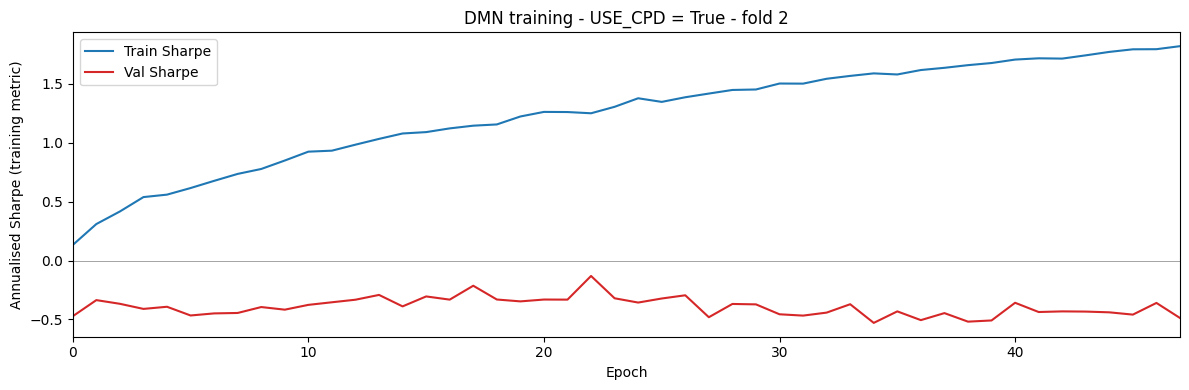

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
epochs = np.arange(len(history["train"]))
ax.plot(epochs, [-l for l in history["train"]], label="Train Sharpe", color="C0")
ax.plot(epochs, [-l for l in history["val"]],   label="Val Sharpe",   color="C3")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Annualised Sharpe (training metric)")
ax.set_title(f"DMN training - USE_CPD = {USE_CPD} - fold {FOLD_IDX}")
ax.set_xlim(epochs[0],epochs[-1])
ax.legend(); plt.tight_layout(); plt.show()

## Out-of-sample evaluation
 
Predict positions on the test set, scale by ex-ante vol, compute the realized strategy return, and report the standard performance metrics.

In [9]:
model.eval()
test_loader = DataLoader(TensorDataset(X_test, R_test, V_test), batch_size=BATCH, shuffle=False)

all_pos, all_ret, all_vol = [], [], []
with torch.no_grad():
    for x, r, v in test_loader:
        x = x.to(DEVICE)
        pos = model(x).cpu().numpy()
        all_pos.append(pos[:, -1])     # only the final position of each sequence
        all_ret.append(r[:, -1].numpy())
        all_vol.append(v[:, -1].numpy())

pos_pred = np.concatenate(all_pos)
ret_real = np.concatenate(all_ret)
vol_pred = np.concatenate(all_vol)

# Vol-scaled strategy return (paper Eq. 11)
strat_ret = pos_pred * (TARGET_VOL / np.maximum(vol_pred, 1e-6)) * ret_real

ann_ret = strat_ret.mean() * 252
ann_vol = strat_ret.std()  * np.sqrt(252)
sharpe  = ann_ret / ann_vol if ann_vol > 0 else float("nan")
hit_rate = (pos_pred * ret_real > 0).mean()

print(f"Out-of-sample metrics (USE_CPD={USE_CPD}, fold {FOLD_IDX}):")
print(f"  Annualised return: {ann_ret:.2%}")
print(f"  Annualised vol:    {ann_vol:.2%}")
print(f"  Sharpe ratio:      {sharpe:+.3f}")
print(f"  Hit rate:          {hit_rate:.1%}")
print(f"  N predictions:     {len(pos_pred):,}")

Out-of-sample metrics (USE_CPD=True, fold 2):
  Annualised return: 0.07%
  Annualised vol:    2.39%
  Sharpe ratio:      +0.029
  Hit rate:          49.9%
  N predictions:     145,252


### Cumulative strategy return
 
Aggregate test-set realised returns over time. Note this is the average across all (asset, date) prediction pairs at each test date, mimicking an equal-weighted portfolio over the in-universe stocks.

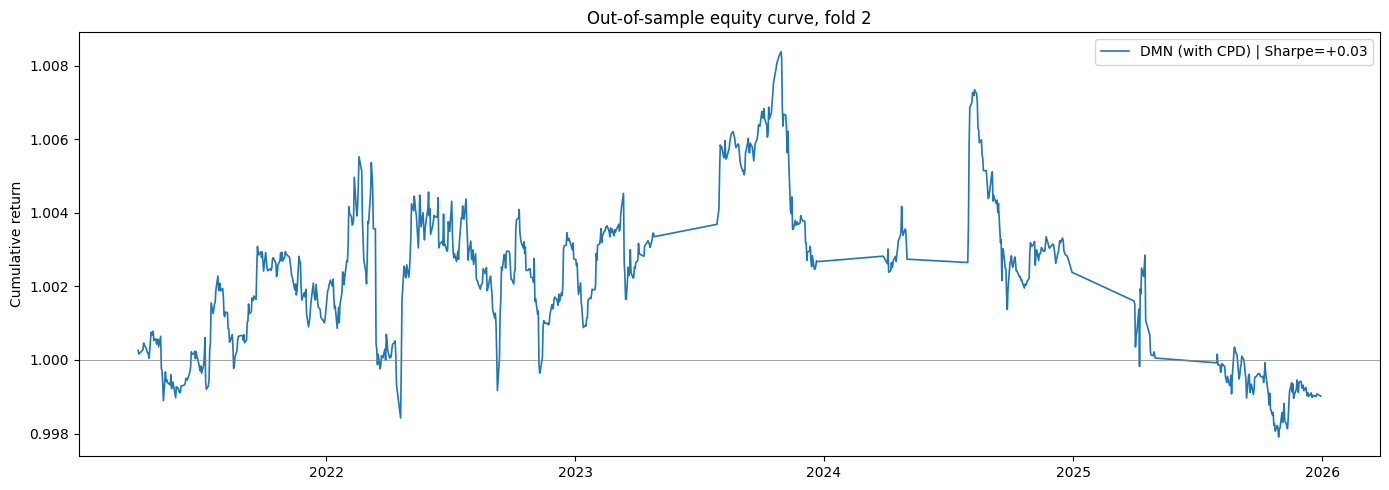

In [ ]:
# Reconstruct (date, ticker) index for test predictions
def test_dates_and_tickers(test_idx, seq_len, n_assets, feats, rets, vol):
    valid_ends = [t for t in test_idx if t - seq_len + 1 >= 0]
    pairs = []
    for t in valid_ends:
        x_block = feats[t - seq_len + 1 : t + 1]
        r_block = rets[t - seq_len + 1 : t + 1]
        v_block = vol[t - seq_len + 1 : t + 1]
        for a in range(n_assets):
            if (np.isfinite(x_block[:, a, :]).all()
                and np.isfinite(r_block[:, a]).all()
                and np.isfinite(v_block[:, a]).all()):
                pairs.append((t, a))
    return pairs

pairs = test_dates_and_tickers(test_idx, SEQ_LEN, feats.shape[1], feats, rets, vol)
test_dates_arr   = np.array([dates[t] for (t, _) in pairs])
test_tickers_arr = np.array([tickers[a] for (_, a) in pairs])

result_df = pd.DataFrame({
    "date":   test_dates_arr,
    "ticker": test_tickers_arr,
    "position":   pos_pred,
    "ret":        ret_real,
    "ex_ante_vol": vol_pred,
    "strat_ret":   strat_ret,
})

ew_strat = result_df.groupby("date")["strat_ret"].mean().sort_index()
cum_strat = (1 + ew_strat).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum_strat.index, cum_strat.values, lw=1.2,
        label=f"DMN ({'with CPD' if USE_CPD else 'baseline'}) | Sharpe={sharpe:+.2f}")
ax.axhline(1.0, color="gray", lw=0.5)
ax.set_title(f"Out-of-sample equity curve, fold {FOLD_IDX}")
ax.set_ylabel("Cumulative return"); ax.legend()
plt.tight_layout(); plt.show()